# ⚡ BiLSTM SOC Prediction — Google Colab GPU
**State of Charge prediction using Bidirectional LSTM**

➡️ Runtime → Change runtime type → **T4 GPU**

In [21]:
# ============================================================
# CELL 1 — Check GPU
# ============================================================
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

CUDA available: True
GPU: Tesla T4
Using device: cuda


In [22]:
# ============================================================
# CELL 2 — Install / Import Libraries
# ============================================================
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, math, os, copy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

torch.manual_seed(42)
np.random.seed(42)
print('All libraries loaded ✅')

All libraries loaded ✅


In [23]:
# ============================================================
# CELL 3 — Upload CSV
# ============================================================
from google.colab import files
uploaded = files.upload()          # Select your Merged.csv
csv_name = list(uploaded.keys())[0]
print('Uploaded:', csv_name)

IndexError: list index out of range

In [1]:
# ============================================================
# CELL 4 — Load & Parse Data
# ============================================================
df = pd.read_csv(csv_name)
df.columns = df.columns.str.strip()
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

def find_col(df, keyword):
    """Case-insensitive column finder"""
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    if not matches:
        raise ValueError(f'Column with keyword "{keyword}" not found. Available: {df.columns.tolist()}')
    return matches[0]

col_velocity    = find_col(df, 'Velocity')
col_elevation   = find_col(df, 'Elevation')
col_throttle    = find_col(df, 'Throttle')
col_torque      = find_col(df, 'MotorTorque')
col_accel       = find_col(df, 'LongitudinalAcceleration')
col_regen       = find_col(df, 'RegenerativeBraking')
col_voltage     = find_col(df, 'BatteryVoltage')
col_current     = find_col(df, 'BatteryCurrent')
col_batttemp    = find_col(df, 'BatteryTemperature')
col_ambtemp     = find_col(df, 'AmbientTemperature')
col_aircon      = find_col(df, 'AirConPower')
col_heater      = find_col(df, 'HeaterCurrent')
col_soc         = find_col(df, 'SoC')

print('\nMapped columns:')
for name, col in [('Velocity',col_velocity),('Voltage',col_voltage),('SOC',col_soc)]:
    print(f'  {name} → {col}')

NameError: name 'pd' is not defined

In [25]:
# ============================================================
# CELL 5 — Feature Engineering
# ============================================================
df['Power']      = df[col_voltage] * df[col_current]          # Instantaneous power
df['dSOC']       = df[col_soc].diff().fillna(0)               # SOC rate of change
df['CumEnergy']  = df['Power'].abs().cumsum()                 # Cumulative energy proxy

feature_cols = [
    col_velocity, col_elevation, col_throttle, col_torque,
    col_accel, col_regen, col_voltage, col_current,
    col_batttemp, col_ambtemp, col_aircon, col_heater,
    'Power', 'dSOC', 'CumEnergy'
]
target_col = col_soc

print(f'Total features: {len(feature_cols)}')
print('Features:', feature_cols)

Total features: 15
Features: ['Velocity_km_h_', 'Elevation_m_', 'Throttle___', 'MotorTorque_Nm_', 'LongitudinalAcceleration_m_s_2_', 'RegenerativeBrakingSignal', 'BatteryVoltage_V_', 'BatteryCurrent_A_', 'BatteryTemperature__C_', 'AmbientTemperature__C_', 'AirConPower_kW_', 'HeaterCurrent_A_', 'Power', 'dSOC', 'CumEnergy']


After NaN removal: 314978 rows
After outlier removal: 197190 rows


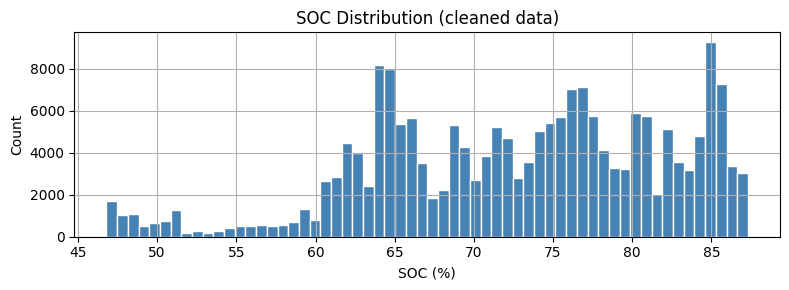

In [26]:
# ============================================================
# CELL 6 — Clean: Drop NaN & Remove Outliers (IQR)
# ============================================================
all_cols = feature_cols + [target_col]
df_clean = df[all_cols].dropna().copy()
print(f'After NaN removal: {len(df_clean)} rows')



# SOC distribution
fig, ax = plt.subplots(figsize=(8,3))
ax.hist(df_clean[target_col], bins=60, color='steelblue', edgecolor='white')
ax.set_title('SOC Distribution (cleaned data)')
ax.set_xlabel('SOC (%)'); ax.set_ylabel('Count'); ax.grid(True)
plt.tight_layout(); plt.show()

In [27]:
# ============================================================
# CELL 7 — Normalize
# ============================================================
X_raw = df_clean[feature_cols].values.astype(np.float32)
Y_raw = df_clean[target_col].values.astype(np.float32)

scaler_X = StandardScaler()
X_norm   = scaler_X.fit_transform(X_raw)

Y_mean, Y_std = Y_raw.mean(), Y_raw.std()
Y_norm        = (Y_raw - Y_mean) / Y_std

print(f'X shape: {X_norm.shape}  |  Y mean: {Y_mean:.2f}  Y std: {Y_std:.2f}')

X shape: (197190, 15)  |  Y mean: 72.71  Y std: 9.27


In [28]:
# ============================================================
# CELL 8 — Sliding Window Sequences
# ============================================================
WINDOW = 30    # timesteps per sequence

X_seq, Y_seq = [], []
for i in range(len(Y_norm) - WINDOW):
    X_seq.append(X_norm[i : i+WINDOW])          # [window, features]
    Y_seq.append(Y_norm[i + WINDOW])

X_seq = np.array(X_seq, dtype=np.float32)       # [N, window, features]
Y_seq = np.array(Y_seq, dtype=np.float32)       # [N]
print(f'Sequences — X: {X_seq.shape}  Y: {Y_seq.shape}')

Sequences — X: (197160, 30, 15)  Y: (197160,)


Train: 157600  |  Test: 39500


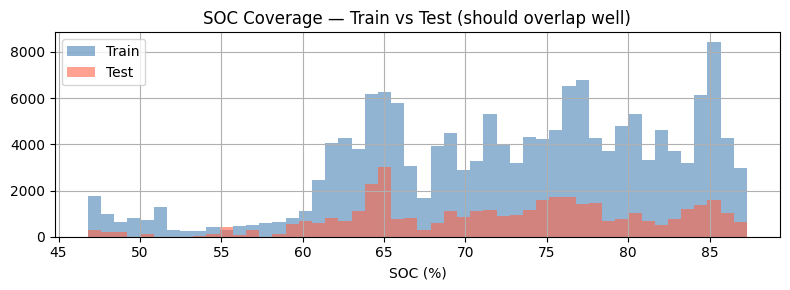

In [29]:
# ============================================================
# CELL 9 — Block-Shuffled Train/Test Split
#   Ensures both sets cover the full SOC range (fixes low R²)
# ============================================================
BLOCK_SIZE = 100
N          = len(Y_seq)
num_blocks = N // BLOCK_SIZE

rng         = np.random.default_rng(42)
block_order = rng.permutation(num_blocks)

n_train      = int(0.8 * num_blocks)
train_blocks = np.sort(block_order[:n_train])
test_blocks  = np.sort(block_order[n_train:])

def blocks_to_idx(blocks, block_size, max_n):
    idx = np.concatenate([np.arange(b*block_size, min((b+1)*block_size, max_n))
                          for b in blocks])
    return np.sort(idx)

train_idx = blocks_to_idx(train_blocks, BLOCK_SIZE, N)
test_idx  = blocks_to_idx(test_blocks,  BLOCK_SIZE, N)

X_train, Y_train = X_seq[train_idx], Y_seq[train_idx]
X_test,  Y_test  = X_seq[test_idx],  Y_seq[test_idx]

print(f'Train: {len(Y_train)}  |  Test: {len(Y_test)}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(Y_train*Y_std+Y_mean, bins=50, alpha=0.6, label='Train', color='steelblue')
ax.hist(Y_test *Y_std+Y_mean, bins=50, alpha=0.6, label='Test',  color='tomato')
ax.set_title('SOC Coverage — Train vs Test (should overlap well)')
ax.set_xlabel('SOC (%)'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

In [30]:
# ============================================================
# CELL 10 — PyTorch Dataset & DataLoader  [OPTIMIZED]
# ============================================================
class SOCDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32).unsqueeze(1)
    def __len__(self):          return len(self.Y)
    def __getitem__(self, i):   return self.X[i], self.Y[i]

BATCH = 512    # Increased from 128 → better GPU utilisation on T4

train_loader = DataLoader(SOCDataset(X_train, Y_train),
                          batch_size=BATCH, shuffle=True,
                          pin_memory=True, num_workers=0)   # 0 avoids Colab overhead
test_loader  = DataLoader(SOCDataset(X_test,  Y_test),
                          batch_size=BATCH, shuffle=False,
                          pin_memory=True, num_workers=0)
print(f'DataLoaders ready ✅  |  Batch size: {BATCH}')

DataLoaders ready ✅  |  Batch size: 512


In [31]:
# ============================================================
# CELL 11 — BiLSTM Model  [OPTIMIZED: smaller but still deep]
# ============================================================
class BiLSTM_SOC(nn.Module):
    def __init__(self, input_size, hidden1=128, hidden2=64,
                 fc1=64, fc2=32, dropout=0.3):
        super().__init__()

        # BiLSTM Layer 1
        self.bilstm1 = nn.LSTM(input_size, hidden1, batch_first=True,
                                bidirectional=True)
        self.norm1   = nn.LayerNorm(hidden1 * 2)
        self.drop1   = nn.Dropout(dropout)

        # BiLSTM Layer 2 — extracts final context
        self.bilstm2 = nn.LSTM(hidden1*2, hidden2, batch_first=True,
                                bidirectional=True)
        self.drop2   = nn.Dropout(dropout - 0.1)

        # Fully Connected Head
        self.fc = nn.Sequential(
            nn.Linear(hidden2*2, fc1),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(fc1, fc2),
            nn.ReLU(),
            nn.Linear(fc2, 1)
        )

    def forward(self, x):               # x: [batch, seq, features]
        out, _ = self.bilstm1(x)
        out     = self.drop1(self.norm1(out))
        out, _ = self.bilstm2(out)
        out     = self.drop2(out[:, -1, :])   # last timestep only
        return self.fc(out)


num_features = X_train.shape[2]
model        = BiLSTM_SOC(input_size=num_features).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {total_params:,}')
print(model)

Model parameters: 324,225
BiLSTM_SOC(
  (bilstm1): LSTM(15, 128, batch_first=True, bidirectional=True)
  (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (bilstm2): LSTM(256, 64, batch_first=True, bidirectional=True)
  (drop2): Dropout(p=0.19999999999999998, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [35]:
# ============================================================
# CELL 12 — Training Setup  [FIXED]
# ============================================================
EPOCHS   = 50
LR       = 1e-3
L2       = 1e-3
PATIENCE = 10

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2)

# verbose=True removed — not supported in PyTorch >= 2.0
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

print(f'PyTorch version : {torch.__version__}')
print(f'Optimizer : Adam  LR={LR}  L2={L2}')
print(f'Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)')
print(f'Epochs    : {EPOCHS}  |  Early stopping patience: {PATIENCE}')

PyTorch version : 2.10.0+cu128
Optimizer : Adam  LR=0.001  L2=0.001
Scheduler : ReduceLROnPlateau (factor=0.5, patience=5)
Epochs    : 50  |  Early stopping patience: 10


In [39]:
# ============================================================
# CELL 13 — Training Loop  [FIXED]
# ============================================================
import time   # <-- fixes NameError

train_losses, val_losses = [], []
best_val_loss    = float('inf')
best_model_wts   = copy.deepcopy(model.state_dict())
patience_counter = 0
epoch_times      = []

header = '{:>6}  {:>12}  {:>10}  {:>10}  {:>10}  {:>8}'.format(
         'Epoch', 'Train Loss', 'Val Loss', 'LR', 'Patience', 'Time(s)')
print(header)
print('-' * 72)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ---- Train ----
    model.train()
    running_loss = 0.0
    for Xb, Yb in train_loader:
        Xb, Yb = Xb.to(device, non_blocking=True), Yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred  = model(Xb)
        loss  = criterion(pred, Yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * Xb.size(0)

    train_loss = running_loss / len(train_loader.dataset)

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, Yb in test_loader:
            Xb, Yb = Xb.to(device, non_blocking=True), Yb.to(device, non_blocking=True)
            val_loss += criterion(model(Xb), Yb).item() * Xb.size(0)
    val_loss /= len(test_loader.dataset)

    elapsed = time.time() - t0
    epoch_times.append(elapsed)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_wts   = copy.deepcopy(model.state_dict())
        patience_counter = 0
        tag = 'BEST'
    else:
        patience_counter += 1
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        print('{:>6}  {:>12.6f}  {:>10.6f}  {:>10.2e}  {:>4}/{:>4}  {:>7.1f}s  {}'.format(
              epoch, train_loss, val_loss, current_lr,
              patience_counter, PATIENCE, elapsed, tag))

    if patience_counter >= PATIENCE:
        print('\nEarly stopping triggered at epoch {} ✅'.format(epoch))
        break

model.load_state_dict(best_model_wts)
print('\nBest Val Loss : {:.6f}'.format(best_val_loss))
print('Avg Epoch Time: {:.1f}s'.format(np.mean(epoch_times)))

 Epoch    Train Loss    Val Loss          LR    Patience   Time(s)
------------------------------------------------------------------------
     1      0.063164    0.003598    1.00e-03     0/  10      8.3s  BEST
     5      0.009880    0.003676    1.00e-03     1/  10      7.7s  
    10      0.008445    0.003205    1.00e-03     2/  10      8.8s  
    15      0.007844    0.003378    1.00e-03     4/  10      7.9s  
    20      0.007148    0.002703    5.00e-04     2/  10      8.0s  
    25      0.006800    0.002567    2.50e-04     7/  10      7.8s  

Early stopping triggered at epoch 28 ✅

Best Val Loss : 0.002542
Avg Epoch Time: 7.9s


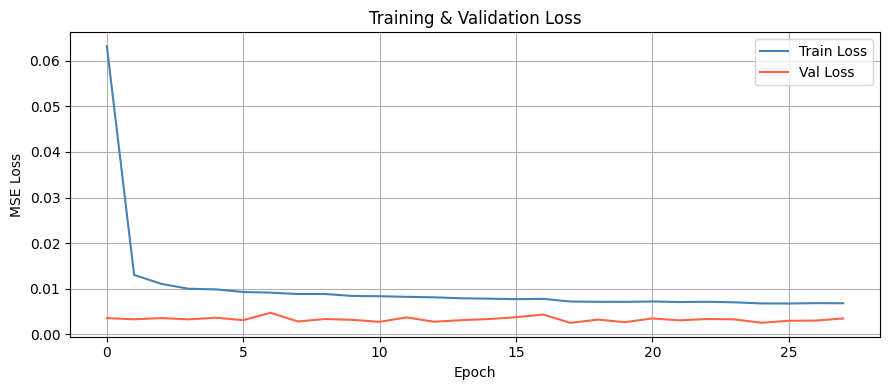

In [40]:
# ============================================================
# CELL 14 — Loss Curve
# ============================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss', color='steelblue', linewidth=1.5)
ax.plot(val_losses,   label='Val Loss',   color='tomato',    linewidth=1.5)
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

In [41]:
# ============================================================
# CELL 15 — Predict & Denormalize
# ============================================================
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for Xb, Yb in test_loader:
        Xb = Xb.to(device)
        pred = model(Xb).cpu().numpy().flatten()
        all_preds.extend(pred)
        all_true.extend(Yb.numpy().flatten())

Y_pred_norm = np.array(all_preds)
Y_true_norm = np.array(all_true)

# Denormalize
Y_pred = Y_pred_norm * Y_std + Y_mean
Y_true = Y_true_norm * Y_std + Y_mean

print(f'Predictions shape: {Y_pred.shape}')

Predictions shape: (39500,)


In [42]:
# ============================================================
# CELL 16 — Metrics
# ============================================================
RMSE = math.sqrt(mean_squared_error(Y_true, Y_pred))
MAE  = mean_absolute_error(Y_true, Y_pred)
R2   = r2_score(Y_true, Y_pred)
MAPE = np.mean(np.abs((Y_true - Y_pred) / (np.abs(Y_true) + 1e-8))) * 100

print('========== BiLSTM PERFORMANCE ==========')
print(f'RMSE = {RMSE:.4f} %')
print(f'MAE  = {MAE:.4f} %')
print(f'MAPE = {MAPE:.2f} %')
print(f'R²   = {R2:.4f}')
print('=========================================')

========== BiLSTM PERFORMANCE ==========
RMSE = 0.4676 %
MAE  = 0.3121 %
MAPE = 0.44 %
R²   = 0.9972


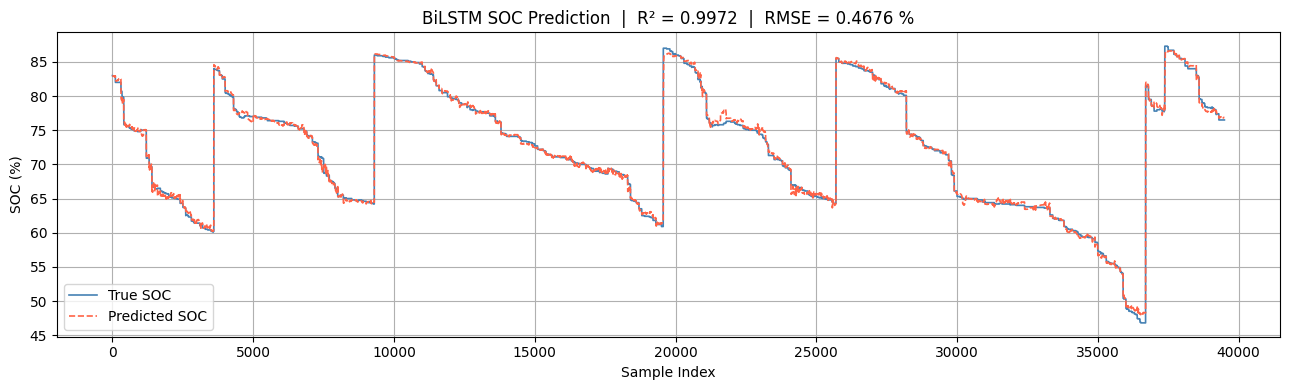

In [43]:
# ============================================================
# CELL 17 — Plot 1: Prediction vs Actual
# ============================================================
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(Y_true, color='steelblue', linewidth=1.2, label='True SOC')
ax.plot(Y_pred, color='tomato',    linewidth=1.2, linestyle='--', label='Predicted SOC')
ax.set_title(f'BiLSTM SOC Prediction  |  R² = {R2:.4f}  |  RMSE = {RMSE:.4f} %')
ax.set_xlabel('Sample Index'); ax.set_ylabel('SOC (%)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('soc_prediction.png', dpi=150); plt.show()

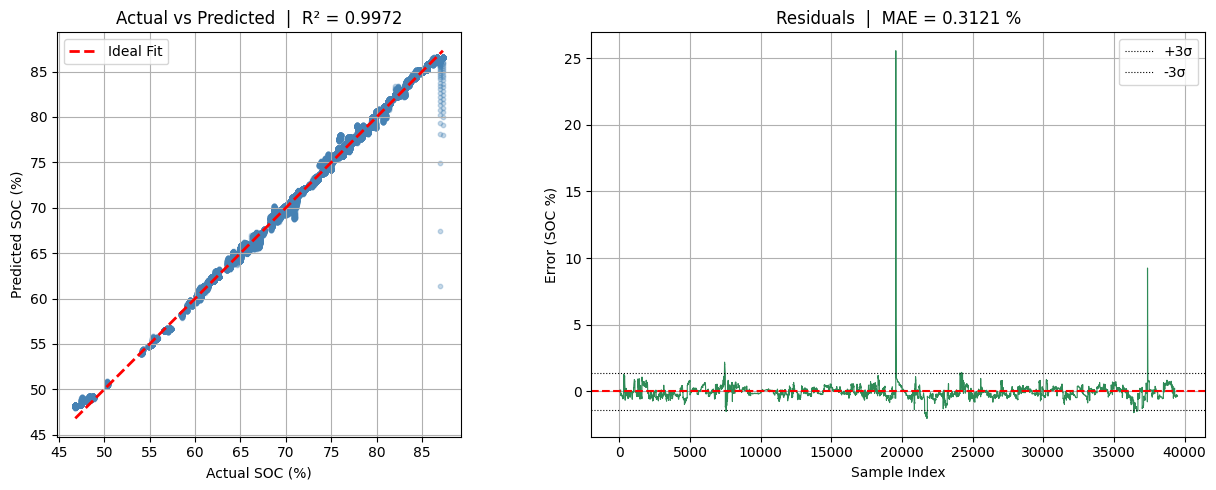

In [44]:
# ============================================================
# CELL 18 — Plot 2: Scatter + Plot 3: Residuals
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
ax = axes[0]
ax.scatter(Y_true, Y_pred, alpha=0.3, s=10, color='steelblue')
ref = [Y_true.min(), Y_true.max()]
ax.plot(ref, ref, 'r--', linewidth=2, label='Ideal Fit')
ax.set_title(f'Actual vs Predicted  |  R² = {R2:.4f}')
ax.set_xlabel('Actual SOC (%)'); ax.set_ylabel('Predicted SOC (%)')
ax.legend(); ax.grid(True); ax.set_aspect('equal', 'box')

# Residuals
residuals = Y_true - Y_pred
ax = axes[1]
ax.plot(residuals, color='seagreen', linewidth=0.8)
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.axhline( 3*RMSE, color='black', linewidth=0.8, linestyle=':', label='+3σ')
ax.axhline(-3*RMSE, color='black', linewidth=0.8, linestyle=':', label='-3σ')
ax.set_title(f'Residuals  |  MAE = {MAE:.4f} %')
ax.set_xlabel('Sample Index'); ax.set_ylabel('Error (SOC %)')
ax.legend(); ax.grid(True)

plt.tight_layout(); plt.savefig('residuals.png', dpi=150); plt.show()

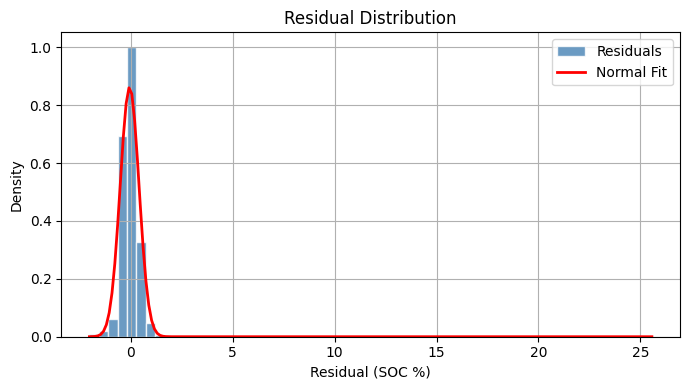

In [45]:
# ============================================================
# CELL 19 — Plot 4: Residual Distribution
# ============================================================
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=60, density=True, color='steelblue',
        edgecolor='white', alpha=0.8, label='Residuals')
xmin, xmax = residuals.min(), residuals.max()
x = np.linspace(xmin, xmax, 200)
mu_r, std_r = stats.norm.fit(residuals)
ax.plot(x, stats.norm.pdf(x, mu_r, std_r), 'r-', linewidth=2, label='Normal Fit')
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual (SOC %)'); ax.set_ylabel('Density')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.savefig('residual_dist.png', dpi=150); plt.show()

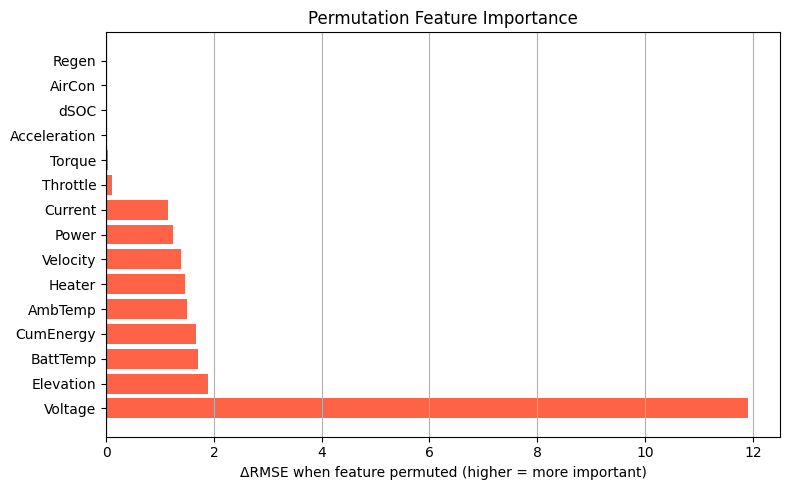

In [46]:
# ============================================================
# CELL 20 — Feature Importance (Permutation)
# ============================================================
feature_names = [
    'Velocity','Elevation','Throttle','Torque','Acceleration','Regen',
    'Voltage','Current','BattTemp','AmbTemp','AirCon','Heater',
    'Power','dSOC','CumEnergy'
]

base_rmse = RMSE
perm_rmse = []

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()
with torch.no_grad():
    for f in range(num_features):
        X_perm = X_test_tensor.clone()
        idx    = torch.randperm(X_perm.shape[0])
        X_perm[:, :, f] = X_perm[idx, :, f]       # shuffle feature f across samples

        preds_perm = []
        for i in range(0, len(X_perm), BATCH):
            batch = X_perm[i:i+BATCH].to(device)
            preds_perm.extend(model(batch).cpu().numpy().flatten())

        Yp_actual = np.array(preds_perm) * Y_std + Y_mean
        perm_rmse.append(math.sqrt(mean_squared_error(Y_true, Yp_actual)))

importance  = np.array(perm_rmse) - base_rmse
sort_idx    = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in importance[sort_idx]]
ax.barh([feature_names[i] for i in sort_idx], importance[sort_idx], color=colors)
ax.set_xlabel('ΔRMSE when feature permuted (higher = more important)')
ax.set_title('Permutation Feature Importance')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(True, axis='x')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150); plt.show()

In [47]:
# ============================================================
# CELL 21 — Save Model & Download
# ============================================================
import joblib

# Save PyTorch model
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler_X':         scaler_X,
    'Y_mean':           Y_mean,
    'Y_std':            Y_std,
    'window_size':      WINDOW,
    'num_features':     num_features,
    'feature_names':    feature_names,
    'metrics': {'RMSE': RMSE, 'MAE': MAE, 'R2': R2, 'MAPE': MAPE}
}, 'bilstm_soc_model.pt')

print('Model saved ✅')
print(f'Final Metrics → R²: {R2:.4f}  RMSE: {RMSE:.4f}%  MAE: {MAE:.4f}%  MAPE: {MAPE:.2f}%')

# Download files
from google.colab import files
files.download('bilstm_soc_model.pt')
files.download('soc_prediction.png')
files.download('residuals.png')
files.download('feature_importance.png')

Model saved ✅
Final Metrics → R²: 0.9972  RMSE: 0.4676%  MAE: 0.3121%  MAPE: 0.44%


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>